In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastai.vision import *
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.models import resnet50
from fastai.core import defaults

In [67]:
path = r'C:\Users\Akshat Bhatt\Downloads\Skin_cancer_dataset\dataset'
csv_file = path + r'\HAM10000_metadata.csv'

In [68]:
df = pd.read_csv(csv_file).set_index('image_id')
df

,lesion_id,dx,dx_type,age,sex,localization,dataset
image_id,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern


In [69]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [70]:
df.dx=df.dx.astype('category',copy=True)
df['labels']=df.dx.cat.codes
df['lesion']= df.dx.map(lesion_type_dict)
df

,lesion_id,dx,dx_type,age,sex,localization,dataset,labels,lesion
image_id,,,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern,2,Benign keratosis
...,...,...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses


In [71]:
print(df.lesion.value_counts())

lesion
Melanocytic nevi        6705
Melanoma                1113
Benign keratosis        1099
Basal cell carcinoma     514
Actinic keratoses        327
Vascular lesions         142
Dermatofibroma           115
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='lesion'>

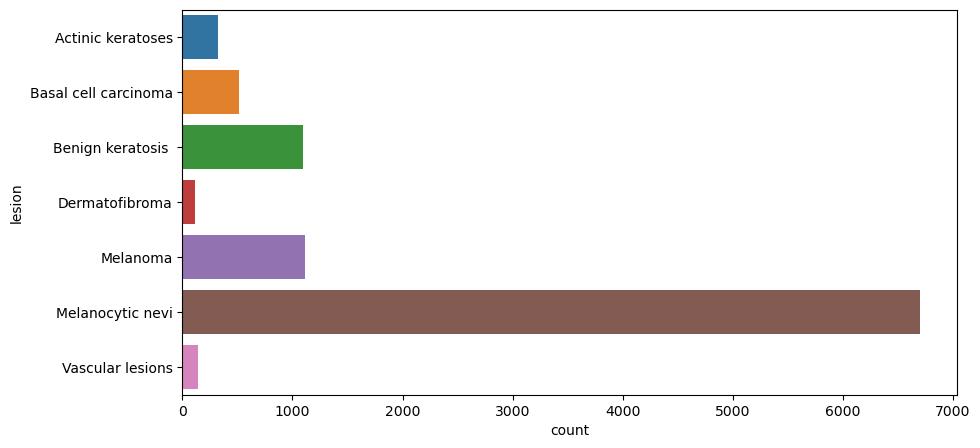

In [72]:
fig, ax1 = plt.subplots(1, 1, figsize = (10, 5))
sns.countplot(y='lesion',data=df, hue="lesion",ax=ax1)

In [73]:
class CustomImageItemList(ImageList):
    def custom_label(self, df, **kwargs) -> 'LabelList':
        file_names = [p.stem for p in self.items]
        get_labels = lambda x: df.loc[x, 'lesion']
        labels = get_labels(file_names)
        y = CategoryList(items=labels)
        res = self._label_list(x=self, y=y)
        return res

In [74]:
import torch
import fastai.vision.transform

 
def patched_solve(B, A):
    return torch.linalg.solve(A, B), None

 
fastai.vision.transform._solve_func = patched_solve

In [75]:
 
def get_data(bs, size):
    train_ds = (CustomImageItemList.from_folder(r'C:\Users\Akshat Bhatt\Downloads\Skin_cancer_dataset\dataset\HAM10000_images_part_1', extensions='.jpg')
                    .split_by_rand_pct(0.15)
                    .custom_label(df)
                    .transform(tfms=get_transforms(flip_vert=True), size=size)
                    .databunch(num_workers=0, bs=bs)
                    .normalize(imagenet_stats))
    return train_ds

In [76]:
data=get_data(16,224)
data

ImageDataBunch;

Train: LabelList (4250 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Melanocytic nevi,Melanocytic nevi,Melanocytic nevi,Melanoma
Path: C:\Users\Akshat Bhatt\Downloads\Skin_cancer_dataset\dataset\HAM10000_images_part_1;

Valid: LabelList (750 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Melanocytic nevi,Actinic keratoses,Actinic keratoses,Melanocytic nevi
Path: C:\Users\Akshat Bhatt\Downloads\Skin_cancer_dataset\dataset\HAM10000_images_part_1;

Test: None

In [77]:
data.classes=list(np.unique(df.lesion))  
data.c= len(np.unique(df.lesion))

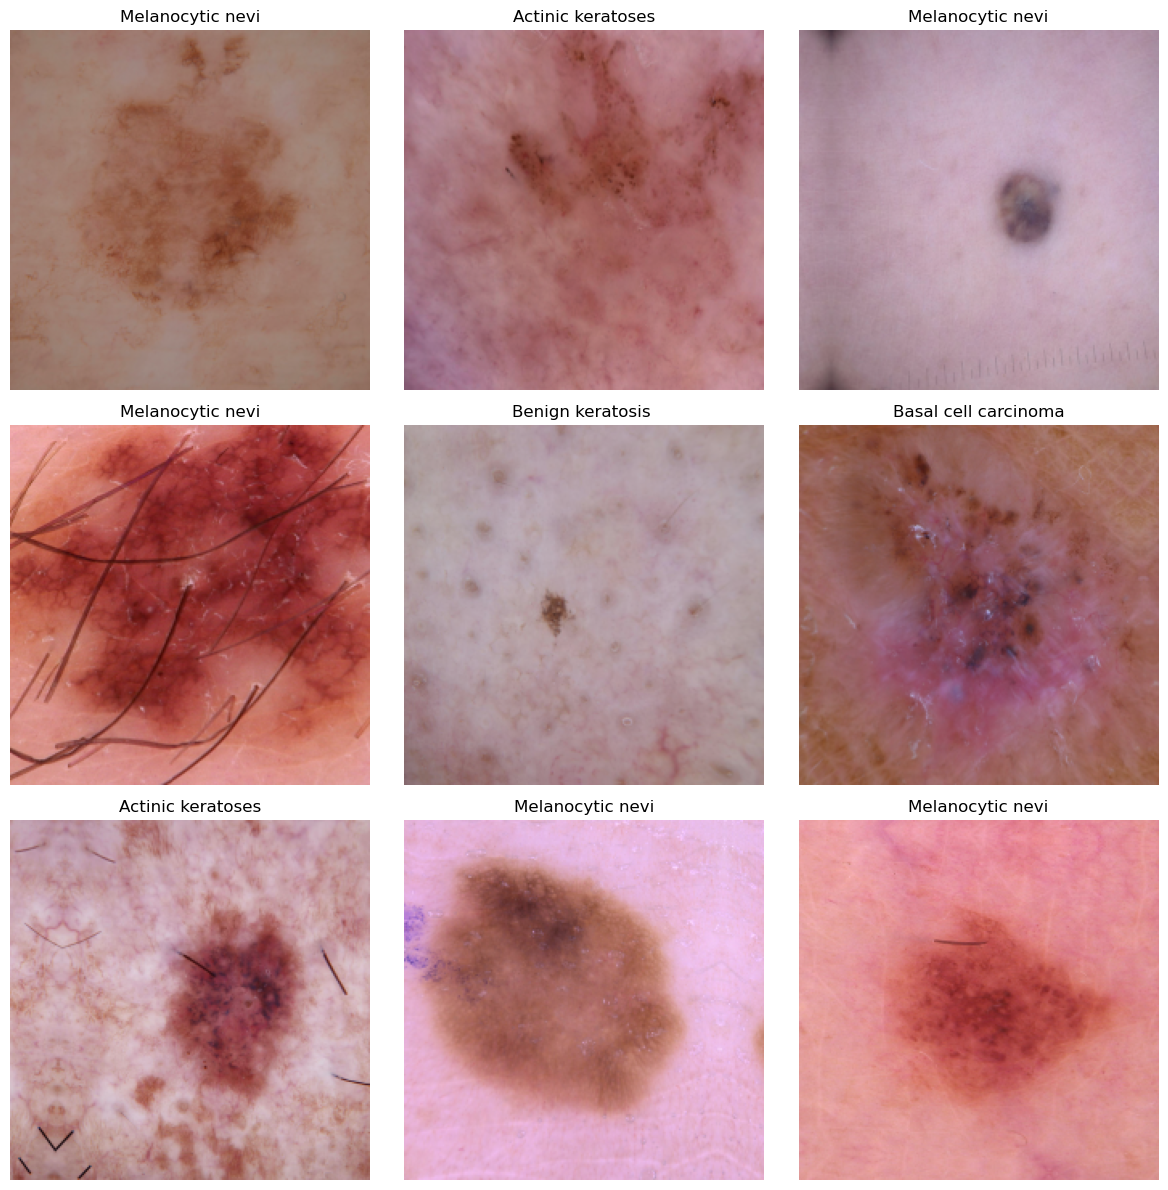

In [78]:
data.show_batch(rows=3)

epoch,train_loss,valid_loss,accuracy,time
0,0.990540,0.907805,0.681333,03:46
1,0.893865,0.821467,0.698667,03:54


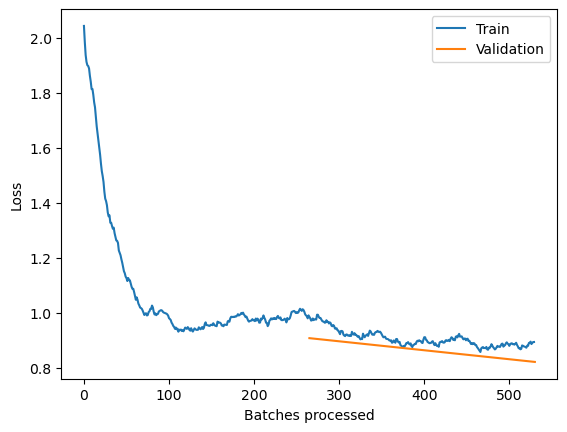

In [79]:
 
 
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        
 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
    
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
      
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
      
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
       
        self.fc1 = nn.Linear(512, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

 
cnn_model = CNN(num_classes=data.c)

  
learn = Learner(data, cnn_model, metrics=accuracy)

learn.fit_one_cycle(2, max_lr=1e-3)
learn.recorder.plot_losses()
 
learn.save('cnn-ham10000-final')
learn.export('cnn-ham10000.pkl')